# Exercise 1

## Problem 1
In this problem we will loog at a very simple machine learning pipeline.
We will load a dataset, perform some exploratory data analysis, train some models, and evaluate their performance.

We will work with the California Housing dataset from https://github.com/ageron/handson-ml2/tree/master/datasets/housing.

Our goal is to predict the `median_house_value` by using the other predictors (i.e., columns) of the dataset.

### 1. Load housing dataset

Import the `numpy` library as `np`, `pandas` library as `pd`, and `matplotlib.pyplot` as `plt`.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


Load the housing dataset `housing.csv` using the `read_csv()` function from `pandas`. Name the dataframe `housing`.


In [89]:
housing = pd.read_csv('/Users/helianferraris/Desktop/Machine Learning/Exercise_01/housing.csv')


### 2. Quick look at the data
The `housing` dataframe is an object of class `DataFrame`. This class has several methods that allow you to look and modify the data. 
Here, we try to understand the dataset by calling the methods `head()`, `info()`, and `describe()`.

* What is the difference between the three methods?

- head(): this function exhibits the same behavior as df[:n], returning the first n rows based on position.
- info(): this method prints information about a DataFrame including the index dtype and columns, non-NA values and memory usage.
- describe(): generate descriptive statistics that include those that summarize the central tendency, dispersion and shape of a dataset’s distribution, excluding NaN values.

* What are the data types of the columns (i.e., quantitative or qualitative)?

The columns 0 to 8 are quantitative. The last one (9th column) is qualitative.

* Are there missing values (e.g., NAs)?

Yes, there are.

* Count the number of rows and column in `housing`.

10 columns and 20640 rows (we can also said that nb entries = nb rows)

In [86]:
housing.head(n=1)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_households,bedrooms_per_total_rooms,population_per_households,rooms_per_bedroom,ocean_proximity_enc
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,0.146591,2.555556,6.821705,3.0


In [95]:
housing.shape #number of rows and columns
  # or len(housing) for the number of rows

20640

In [88]:
housing.describe()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_households,bedrooms_per_total_rooms,population_per_households,rooms_per_bedroom,ocean_proximity_enc
count,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000
mean,-119.570689,35.633221,28.633094,2636.504233,537.870553,1424.946949,499.433465,3.871162,206864.413155,5.431344,0.213039,3.071533,4.984829,1.166153
std,2.003578,2.136348,12.591805,2185.269567,421.385070,1133.208490,382.299226,1.899291,115435.667099,2.482946,0.057983,10.438269,1.171676,1.420135
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,0.846154,0.100000,0.692308,1.000000,0.000000
25%,-121.800000,33.930000,18.000000,1450.000000,296.000000,787.000000,280.000000,2.563700,119500.000000,4.441441,0.175427,2.429032,4.169782,0.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.536500,179700.000000,5.230769,0.203162,2.817582,4.922170,1.000000
75%,-118.010000,37.720000,37.000000,3143.000000,647.000000,1722.000000,604.000000,4.744000,264700.000000,6.052381,0.239821,3.281513,5.700364,1.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000,141.909091,1.000000,1243.333333,10.000000,4.000000


In [90]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [16]:
housing.isnull().any()
# or housing.isna()

longitude             False
latitude              False
housing_median_age    False
total_rooms           False
total_bedrooms         True
population            False
households            False
median_income         False
median_house_value    False
ocean_proximity       False
dtype: bool

In [92]:
housing.isna().sum()

# isna = isnull

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

### 3. Exploratory data analysis

We want to better understand the dataset at hand by performing some exploratory data analysis.

Import the `scatter_matrix` function from the `plotting` submodule of `pandas`.

In [97]:
from pandas.plotting import scatter_matrix

Call the `scatter_matrix` and `corr` function on the quantitative variables of the `housing` dataset.

array([[<Axes: xlabel='longitude', ylabel='longitude'>,
        <Axes: xlabel='latitude', ylabel='longitude'>,
        <Axes: xlabel='housing_median_age', ylabel='longitude'>,
        <Axes: xlabel='total_rooms', ylabel='longitude'>,
        <Axes: xlabel='total_bedrooms', ylabel='longitude'>,
        <Axes: xlabel='population', ylabel='longitude'>,
        <Axes: xlabel='households', ylabel='longitude'>,
        <Axes: xlabel='median_income', ylabel='longitude'>,
        <Axes: xlabel='median_house_value', ylabel='longitude'>],
       [<Axes: xlabel='longitude', ylabel='latitude'>,
        <Axes: xlabel='latitude', ylabel='latitude'>,
        <Axes: xlabel='housing_median_age', ylabel='latitude'>,
        <Axes: xlabel='total_rooms', ylabel='latitude'>,
        <Axes: xlabel='total_bedrooms', ylabel='latitude'>,
        <Axes: xlabel='population', ylabel='latitude'>,
        <Axes: xlabel='households', ylabel='latitude'>,
        <Axes: xlabel='median_income', ylabel='latitude'>,
    

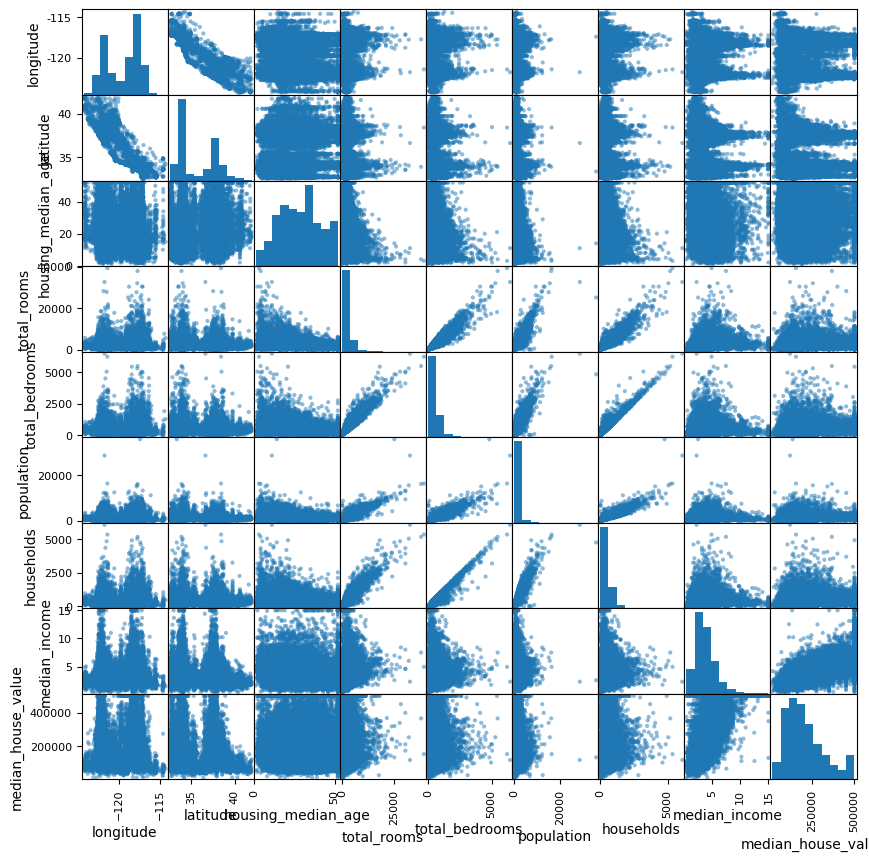

In [100]:
quant_df = housing.drop(columns='ocean_proximity')

# or quant_df = housing.drop('ocean_proximity, axis = 1)
# or quant_df = housing.drop('ocean_proximity, axis = 'columns')

scatter_matrix(quant_df, figsize = (10, 10))
# scatter_matrix(housing.iloc[:, 0:9])

In [101]:
quant_df.corr()
#housing.iloc[:, 0:9].corr() #This calculates the correlation coefficient between every pair of quantitative variables.

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


Can you explain the strong negative correlation between `latitude` and `longitude`?

The strong negative correlation between these two variables means that there is a strong negative linear relationship between them. They are negatively correlated, i.e. when one increases the other decreases.

<Axes: xlabel='longitude', ylabel='latitude'>

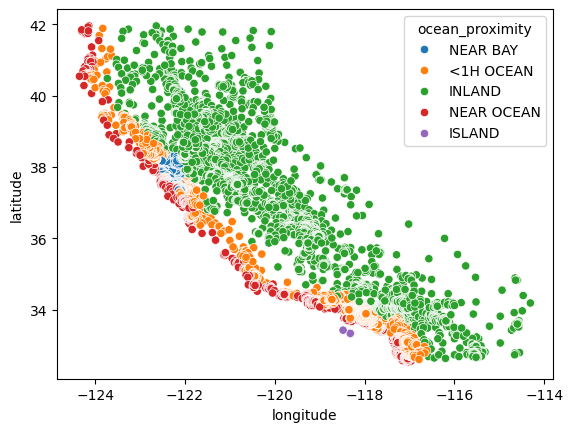

In [103]:
import seaborn as sns

sns.scatterplot(data = housing, x='longitude', y='latitude', hue = 'ocean_proximity')

Above we had to ignore the qualitative variable `ocean_proximity`. How could we analyze the relationship between `ocean_proximity` and the target variable `median_house_value`?

The houses in the different ocean_proximity categories have noticeably different average median_house_value values. In general, the coastal categories have higher house values than the INLAND category. The differences between the categories are quite large.

In [105]:
# print(housing.iloc[:,8:10])
housing["ocean_proximity"].unique() # 5 categories

housing.groupby(['ocean_proximity']).mean()
#or housing.groupby(by ='ocean_proximity').mean()
# or if we want just for median_house_value --> housing.groupby(['ocean_proximity']).mean()[['median_house_value']]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
ocean_proximity,,,,,,,,,
<1H OCEAN,-118.847766,34.560577,29.279225,2628.343586,546.539185,1520.290499,517.744965,4.230682,240084.285464
INLAND,-119.732990,36.731829,24.271867,2717.742787,533.881619,1391.046252,477.447565,3.208996,124805.392001
ISLAND,-118.354000,33.358000,42.400000,1574.600000,420.400000,668.000000,276.600000,2.744420,380440.000000
NEAR BAY,-122.260694,37.801057,37.730131,2493.589520,514.182819,1230.317467,488.616157,4.172885,259212.311790
NEAR OCEAN,-119.332555,34.738439,29.347254,2583.700903,538.615677,1354.008653,501.244545,4.005785,249433.977427


In [106]:
housing.groupby("ocean_proximity").median()[['median_house_value']]
# here we have the median but only shown for median_house_value, if we want for all variable we just remove the [['median_house_value']]

,median_house_value
ocean_proximity,
<1H OCEAN,214850.0
INLAND,108500.0
ISLAND,414700.0
NEAR BAY,233800.0
NEAR OCEAN,229450.0


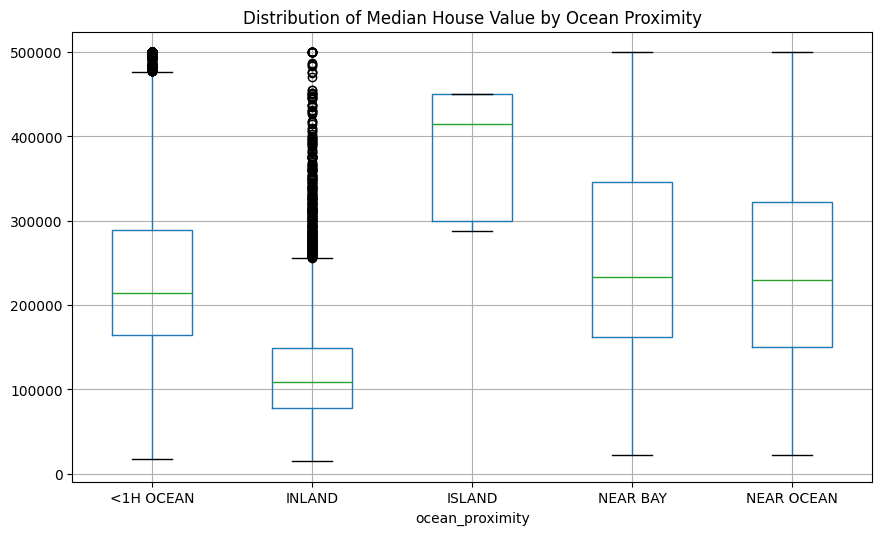

In [107]:
housing.boxplot(column='median_house_value', by='ocean_proximity', figsize=(10, 6))
plt.title('Distribution of Median House Value by Ocean Proximity')
plt.suptitle('')  # Remove the automatic title that boxplot adds
plt.show()

What is the most promising feature to predict `median_house_value`?

It's median_income. We can look back at the scatter plot matrix (point 3). ocean_proximity is also pretty descent.

In [41]:
corr_median = housing.iloc[:, 0:9].corr()['median_house_value'] #uniquement les corrélations de median_house_value avec les autres variables
corr_median = corr_median.drop('median_house_value') # remove median_house_value
print(corr_median)
print('The most promising feature to predict median_house_value is', corr_median.abs().idxmax(), 'with value', max(round(corr_median,3)))


longitude            -0.045967
latitude             -0.144160
housing_median_age    0.105623
total_rooms           0.134153
total_bedrooms        0.049686
population           -0.024650
households            0.065843
median_income         0.688075
Name: median_house_value, dtype: float64
The most promising feature to predict median_house_value is median_income with value 0.688


Are there some features that are strongly correlated with each other?

Yes, household, number of rooms, number of bedrooms and population are all absolute counts of one block of land. income and house value are also correlated.

In [112]:
corr = quant_df.corr()
corr_without_self = corr.mask(corr == 1) # remplace les 1.0 de la diagonale par NaN.

corr_without_self.abs().max()
corr_without_self.abs().idxmax()

longitude                       latitude
latitude                       longitude
housing_median_age           total_rooms
total_rooms               total_bedrooms
total_bedrooms                households
population                    households
households                total_bedrooms
median_income         median_house_value
median_house_value         median_income
dtype: object

*Optional*: Some of the scatter plots (above and in the following) look more informative if you remove "outliers" using the following function.

In [42]:
def remove_outliers(data, lower_quantile=0.01, upper_quantile=0.99):
    """
    Remove outliers from each column in a quantitative (!) DataFrame based on quantile thresholds.
    Keeps only rows where all columns are within the specified quantile range.
    Returns a new DataFrame without outliers.
    """
    quantiles = data.quantile([lower_quantile, upper_quantile])
    df_filtered = data.apply(
        lambda col: col[(col >= quantiles.loc[lower_quantile, col.name]) & (col <= quantiles.loc[upper_quantile, col.name])]
    ).dropna()
    return df_filtered


### 4. Simple data transformations

Here, we perform some data transformations, such as data cleaning and feature engineering.

#### 4.1 Data cleaning

Let us start by removing any row containing NAs.

In [113]:
housing = housing.dropna() # returns a *new* dataframe without the na
housing.dropna(inplace = True) # modifies existing dataframe by removing the na rows
housing.shape

(20433, 10)

#### 4.2 Feature engineering

Consider the columns `total_rooms` and `total_bedrooms`, which describe the total number of rooms and bedrooms in a district, and  `population` and `households`, which describe the population and the number of households in a district.
However, the total number of rooms in a district is not very informative if we don't know the number of households.
Similarly, the number of bedrooms might be more useful if we put it in relation to the total number of rooms.
Finally, one might be interested in the number of people per household, rather than the total population itself.

Based on the observations above, create three new features (i.e., columns) that can be more useful than the existing  `total_rooms`, `total_bedrooms`, `population`, and `households`.

In [118]:

housing["rooms_per_household"] = housing["total_rooms"] / housing["households"]
housing["rooms_per_bedroom"] = housing["total_rooms"] / housing["total_bedrooms"]
housing["people_per_household"] = housing["population"] / housing["households"]
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_households,rooms_per_bedroom,population_per_households,rooms_per_household,people_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,6.821705,2.555556,6.984127,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,6.418626,2.109842,6.238137,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,7.721053,2.802260,8.288136,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,5.421277,2.547945,5.817352,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,5.810714,2.181467,6.281853,2.181467
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,5.045455,4.451872,2.560606,5.045455,2.560606
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,6.114035,4.646667,3.122807,6.114035,3.122807
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,5.205543,4.647423,2.325635,5.205543,2.325635
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,5.329513,4.547677,2.123209,5.329513,2.123209


At this point, look at the scatter matrix of the newly created columns.

array([[<Axes: xlabel='rooms_per_bedroom', ylabel='rooms_per_bedroom'>,
        <Axes: xlabel='rooms_per_household', ylabel='rooms_per_bedroom'>,
        <Axes: xlabel='people_per_household', ylabel='rooms_per_bedroom'>,
        <Axes: xlabel='median_house_value', ylabel='rooms_per_bedroom'>],
       [<Axes: xlabel='rooms_per_bedroom', ylabel='rooms_per_household'>,
        <Axes: xlabel='rooms_per_household', ylabel='rooms_per_household'>,
        <Axes: xlabel='people_per_household', ylabel='rooms_per_household'>,
        <Axes: xlabel='median_house_value', ylabel='rooms_per_household'>],
       [<Axes: xlabel='rooms_per_bedroom', ylabel='people_per_household'>,
        <Axes: xlabel='rooms_per_household', ylabel='people_per_household'>,
        <Axes: xlabel='people_per_household', ylabel='people_per_household'>,
        <Axes: xlabel='median_house_value', ylabel='people_per_household'>],
       [<Axes: xlabel='rooms_per_bedroom', ylabel='median_house_value'>,
        <Axes: xlabel=

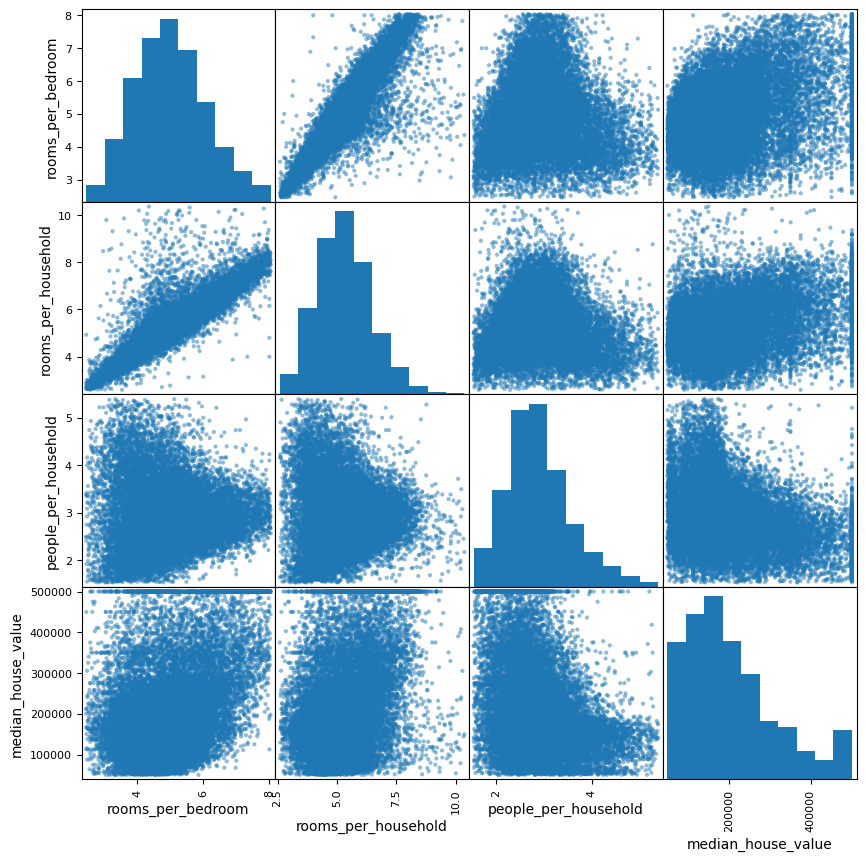

In [119]:
new_vars = housing[["rooms_per_bedroom", "rooms_per_household", "people_per_household", "median_house_value"]]
new_vars = remove_outliers(new_vars) # remove_outliers is a function created earlier (optional point above)

scatter_matrix(new_vars, figsize = (10, 10)) # figsize=(10, 10) augmente la taille de toute la figure.

In [132]:
# we can also look at a scatter plot matrix for all the variables in housing
scatter_matrix(housing, figsize = (20, 20))

array([[<Axes: xlabel='longitude', ylabel='longitude'>,
        <Axes: xlabel='latitude', ylabel='longitude'>,
        <Axes: xlabel='housing_median_age', ylabel='longitude'>,
        <Axes: xlabel='total_rooms', ylabel='longitude'>,
        <Axes: xlabel='total_bedrooms', ylabel='longitude'>,
        <Axes: xlabel='population', ylabel='longitude'>,
        <Axes: xlabel='households', ylabel='longitude'>,
        <Axes: xlabel='median_income', ylabel='longitude'>,
        <Axes: xlabel='median_house_value', ylabel='longitude'>,
        <Axes: xlabel='rooms_per_households', ylabel='longitude'>,
        <Axes: xlabel='rooms_per_bedroom', ylabel='longitude'>,
        <Axes: xlabel='population_per_households', ylabel='longitude'>,
        <Axes: xlabel='rooms_per_household', ylabel='longitude'>,
        <Axes: xlabel='people_per_household', ylabel='longitude'>],
       [<Axes: xlabel='longitude', ylabel='latitude'>,
        <Axes: xlabel='latitude', ylabel='latitude'>,
        <Axes: xlabe

Error in callback <function flush_figures at 0x10bdd08b0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

Compute the correlation among the new variables. Also, compute the correlation between  `total_rooms`, `total_bedrooms`, `population`, and `households`. What do you observe?

In [133]:
new_vars.corr()

,rooms_per_bedroom,rooms_per_household,people_per_household,median_house_value
rooms_per_bedroom,1.000000,0.873978,0.005602,0.365723
rooms_per_household,0.873978,1.000000,-0.046285,0.311659
people_per_household,0.005602,-0.046285,1.000000,-0.298935
median_house_value,0.365723,0.311659,-0.298935,1.000000


In [129]:
housing.drop(columns='ocean_proximity').corr()

# see all the correlations with the 3 new features

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_households,rooms_per_bedroom,population_per_households,rooms_per_household,people_per_household
longitude,1.000000,-0.924616,-0.109357,0.045480,0.069608,0.100270,0.056513,-0.015550,-0.045398,-0.027307,-0.079510,0.002304,-0.027307,0.002304
latitude,-0.924616,1.000000,0.011899,-0.036667,-0.066983,-0.108997,-0.071774,-0.079626,-0.144638,0.106423,0.084902,0.002522,0.106423,0.002522
housing_median_age,-0.109357,0.011899,1.000000,-0.360628,-0.320451,-0.295787,-0.302768,-0.118278,0.106432,-0.153031,-0.160853,0.013258,-0.153031,0.013258
total_rooms,0.045480,-0.036667,-0.360628,1.000000,0.930380,0.857281,0.918992,0.197882,0.133294,0.133482,0.197684,-0.024596,0.133482,-0.024596
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686,0.001538,-0.090517,-0.028355,0.001538,-0.028355
population,0.100270,-0.108997,-0.295787,0.857281,0.877747,1.000000,0.907186,0.005087,-0.025300,-0.071898,-0.032065,0.070062,-0.071898,0.070062
households,0.056513,-0.071774,-0.302768,0.918992,0.979728,0.907186,1.000000,0.013434,0.064894,-0.080165,-0.067736,-0.027336,-0.080165,-0.027336
median_income,-0.015550,-0.079626,-0.118278,0.197882,-0.007723,0.005087,0.013434,1.000000,0.688355,0.325307,0.766578,0.018894,0.325307,0.018894
median_house_value,-0.045398,-0.144638,0.106432,0.133294,0.049686,-0.025300,0.064894,0.688355,1.000000,0.151344,0.383920,-0.023639,0.151344,-0.023639
rooms_per_households,-0.027307,0.106423,-0.153031,0.133482,0.001538,-0.071898,-0.080165,0.325307,0.151344,1.000000,0.445081,-0.004873,1.000000,-0.004873


#### 4.3 Categorical variables

The column `ocean_proximity` is a qualitative variable with different categories. It is always good to convert qualitative variables into quantitative before fitting machine learning models. To do so, we will use the `OrdinalEncoder` function from the `preprocessing` package of the `sklearn` library.

Import the `OrdinalEncoder` class.

In [136]:
from sklearn.preprocessing import OrdinalEncoder

We first instantiate an object from class `OrdinalEncoder` and we call it `my_ordinal_encoder`.

In [143]:
my_ordinal_encoder = OrdinalEncoder()
# print(type(my_ordinal_encoder))

my_ordinal_encoder = OrdinalEncoder(categories = [['ISLAND', 'NEAR OCEAN','NEAR BAY', '<1H OCEAN', 'INLAND']])
#this second part is optional, we explicitly give the order to encode (arbitrary), we also let Python encode by default but it could be less logic



Create a new column named `ocean_proximity_enc` by transforming the `ocean_proximity` column with the `my_ordinal_encoder.fit_transform` function.

_Hint_: Make sure you access the `ocean_proximity` column with the double bracket `[[` and not with the single bracket `[`.

In [144]:
housing['ocean_proximity_enc'] = my_ordinal_encoder.fit_transform(housing[['ocean_proximity']])
#we could also put x = housing[['ocean_proximity']] but the x = is optional
#2 crochets pour garder la forme dataframe, un crochet donne la forme de serie

housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_households,rooms_per_bedroom,population_per_households,rooms_per_household,people_per_household,ocean_proximity_enc
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,6.821705,2.555556,6.984127,2.555556,2.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,6.418626,2.109842,6.238137,2.109842,2.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,7.721053,2.802260,8.288136,2.802260,2.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,5.421277,2.547945,5.817352,2.547945,2.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,5.810714,2.181467,6.281853,2.181467,2.0


### 5. Prepare data for machine learning algorithms

Create a "clean" dataset, without the columns `total_rooms`, `total_bedrooms`, `population`, `households`, and `ocean_proximity`.
Split the new dataset into predictors `X` and response `y`. 

In [158]:
clean_housing = housing.drop(columns=['ocean_proximity',
                              'total_rooms',
                              'households',
                              'total_bedrooms',
                              'population'])
# works the same as --> housing_clean = housing.drop(["total_rooms", "total_bedrooms", "population", "households", "ocean_proximity"], axis = "columns")

#clean_housing = clean_housing.dropna()
y = clean_housing['median_house_value']

X = clean_housing.drop(columns=['median_house_value'])
 # equivalently X = housing_clean.drop(["median_house_value"], axis = "columns")


If we fit and evaluate our model on the same data we obtain overly optimistic results. For this reason, we have to split the dataset into a train and test part.

*Note: See next week's slides for details on this concept*

Split the data by keeping 20% of the observations in the test set. Set the random seed to `42`.
(Replace the `??` below)

In [159]:
from sklearn.model_selection import train_test_split

In [160]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 20/100, random_state = 42) # 20/100 because we want a percentage

### 6. Fit simple models

We are now ready to fit our first two models, KNN and LinearRegression.

Let us first fit a KNN model with $k=8$.

In [161]:
from sklearn.neighbors import KNeighborsRegressor

In [162]:
knn = KNeighborsRegressor(n_neighbors=8)
knn.fit(X_train,y_train)

KNeighborsRegressor(n_neighbors=8)

Let us now fit a Linear Regression model.

In [163]:
from sklearn.linear_model import LinearRegression

In [164]:
lin_reg = LinearRegression()
lin_reg.fit(X_train,y_train)

LinearRegression()

### 7. Make predictions and evaluate models

We now want to make some predictions on test set, i.e., `X_test`, and to evaluate how well the models perform.

Predict the fitted models on the test set `X_test` and store the predictions in `knn_preds` and `lin_reg_preds`, respectively.

_Hint_: use the `<fitted_object>.predict` method.

In [165]:
knn_preds = knn.predict(X_test)
knn_preds

array([197712.5, 150637.5, 215312.5, ...,  98987.5, 132612.5, 118075. ])

In [166]:
lin_reg_preds = lin_reg.predict(X_test)
lin_reg_preds

array([226471.97981885, 169421.6127461 , 195866.61499015, ...,
       110991.08570684, 143590.75652925, 174478.95885867])

Evaluate the performance of the models using the root mean square error (RMSE). Fill the `??`.

In [167]:
from sklearn.metrics import root_mean_squared_error

In [168]:
root_mean_squared_error(knn_preds, y_test)

61399.64617190751

In [171]:
root_mean_squared_error(lin_reg_preds,y_test)

73091.54083495015

*Optional:* Can you also compute these errors without using any library function (i.e., by using only `numpy`)?

In [172]:
np.sqrt(np.mean((knn_preds - y_test)**2, axis=0))

np.float64(61399.64617190751)

In [173]:
np.sqrt(np.mean((lin_reg_preds - y_test)**2, axis=0))

np.float64(73091.54083495015)

## Problem 2


In this problem, we show that the regression function $f^*(x) := \operatorname{E}[Y \mid X = x]$, $x \in \mathbb{R}^p$, is **optimal** in the sense that it minimizes the expected squared prediction error.

In particular, for a fixed predictor value $x \in \mathbb{R}^p$, show that

$$f^*(x) = 
\underset{f(x)}{\operatorname{arg min}} \operatorname{E}\left[\left(Y - f(x)\right)^2 \mid X = x\right].$$